# Stage 3 · Flow Matching Before a Frozen Linear Classifier

**CVLAB Summer Project — few-shot classification with Flow Matching · DTD / ResNet-18 · FGVC-Aircraft / DINOv2**

<p style="font-size:1.5em; text-align:center; margin:1.1em 0 1.1em 0;">
Image → Frozen Encoder → <b>z</b> → <b>Flow Matching</b> → <b>ẑ</b> → Frozen Linear Classifier → Prediction
</p>

**Research question:** can a Flow-Matching transformation, inserted *before* the frozen Stage-1 linear classifier, turn frozen encoder features into a representation that the *existing* classifier separates better?

- The classifier is trained first, exactly as in Stage 1, then frozen; the FM starts as an exact identity, so before training the system *is* the Stage-1 probe.
- Two FM training strategies are compared against that probe on two datasets, with the test split sealed until one final read-out.

*Presentation version (≈ 28 min) of `stage3_presentation.ipynb`, the complete scientific report; every number here is read from the same tables of record. Reference material sits in the Appendix.*

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> שלב 3 שואל האם שכבת Flow Matching שמוכנסת <u>לפני</u> מסווג ליניארי קפוא יכולה "לשפר את הפיצ'רים" כך שאותו מסווג בדיוק יסווג טוב יותר.</p>
<p><b>מונחים בפשטות:</b> <b>Frozen encoder</b> — רשת מאומנת מראש (ResNet-18 / DINOv2) שרק מחלצת פיצ'רים ולא מתעדכנת. <b>z</b> — וקטור הפיצ'רים של תמונה. <b>Flow Matching (FM)</b> — רשת קטנה שלומדת "שדה מהירות" ומזיזה את z בכמה צעדי Euler קטנים אל ẑ. <b>Linear probe</b> — המסווג הליניארי s = Wz + b שאומן בשלב 1.</p>
<p><b>מה לומר על השקף:</b> לעבור על הצינור משמאל לימין ולהדגיש ששני הקצוות קפואים ורק ה-FM באמצע מתאמן. לפני האימון ה-FM הוא זהות מדויקת, ולכן נקודת ההתחלה היא בדיוק הביצועים של שלב 1 — כל שיפור נמדד ממנה.</p>
<p><b>שאלה צפויה:</b> "למה לא לאמן את המסווג יחד עם ה-FM?" — <b>תשובה:</b> זו הגדרת השלב במפרט: ייצוג טוב יותר עבור מסווג קיים. אימון משותף נבדק כהרחבה אופציונלית (נספח A.7) ולא הראה עדות ליתרון מעבר לאימון המסווג לבד.</p>
<p><b>זמן משוער:</b> ~2 דקות (סה"כ מתוכנן ~28 דקות ל-10 השקפים).</p>
</div></details>

In [1]:
# Hidden setup — paths, config, display-name maps. Everything downstream READS
# the tables, histories and figures of record under results/; nothing is
# recomputed or written back.
import io
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.utils import load_config                       # sets KMP_DUPLICATE_LIB_OK before torch
from src.visualize import dataset_label, encoder_label  # display-name maps (+ figure theme)

pd.set_option("display.precision", 2)
pd.set_option("display.max_rows", 200)
cfg = load_config()
MET = REPO / "results" / "metrics"
FIG = REPO / "results" / "figures"

## 1 · Why Stage 3 — the setup in four bullets

- **Encoder and Stage-1 linear probe are frozen.** The probe is retrained per (dataset, subset seed) with the exact Stage-1 recipe and pinned: it is the baseline *and* the classifier inside the pipeline.
- **Only the FM is trained.** Velocity MLP $d{+}1 \to 512 \to 512 \to d$ (SiLU), $T = 4$ Euler steps, $\hat{z}_{k+1} = \hat{z}_k + \tfrac{1}{T}\,v_\theta(\hat{z}_k, k/T)$, in the **raw** feature space the probe was trained in.
- **Exact identity at initialization.** The final velocity layer starts at zero (weight *and* bias), so $\hat{z} = z$ bit-for-bit: the pipeline starts at exactly the probe's accuracy, and every Δ is measured from there.
- **Goal: better features for the existing classifier** — not a new classifier. Any gain must come from moving $z$ to a $\hat{z}$ that the fixed boundary $W x + b$ separates better.

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> ארבע עובדות שמגדירות את הניסוי — מה קפוא, מה מתאמן, מאיפה מתחילים (זהות מדויקת), ומה המטרה.</p>
<p><b>מונחים בפשטות:</b> <b>Velocity network</b> — MLP שמקבל (ẑ_k, t) ומחזיר כיוון תזוזה. <b>Euler steps</b> — T = 4 צעדים קטנים שמצטברים לתזוזה הכוללת. <b>Raw feature space</b> — עובדים על הפיצ'רים כפי שהם, בלי נרמול, כי המסווג אומן עליהם כך (בשלב 2 המסווג היה מבוסס קוסינוס ולכן שם עבדנו על הספירה). <b>Identity at init</b> — השכבה האחרונה של רשת המהירות מאותחלת לאפס ולכן ẑ = z בדיוק.</p>
<p><b>מה לומר על הנוסחה:</b> צעד Euler — כל צעד מוסיף 1/T כפול המהירות; ארבעה צעדים כאלה. ה-FM לא מחליף את המסווג אלא "מכין" לו קלט. ה-FM הוא רשת קטנה (~0.8M פרמטרים ב-DTD, ~0.66M ב-FGVC).</p>
<p><b>שאלה צפויה:</b> "למה זהות <u>מדויקת</u> ולא רק 'קרוב לזהות'?" — <b>תשובה:</b> כך ה-Δ נמדד מנקודת התחלה שהיא בדיוק ה-probe של שלב 1 (נבדק ברמת ביט, לוגיטים ותחזיות — נספח A.2), ואין שינוי ביצועים "חינם" שנובע מרעש אתחול.</p>
<p><b>זמן משוער:</b> ~2 דקות.</p>
</div></details>

## 2 · Strategy 1 — end-to-end rolled-out classification training

- Run the full $T$-step rollout $z \to \hat{z}$, pass $\hat{z}$ through the **frozen** classifier, and backpropagate the cross-entropy **through the whole rollout** — updating **only** the FM parameters.
- A **relative displacement regularizer** discourages unnecessarily large moves (scale-free, so it means the same thing on both datasets):

$$\mathcal{L}_{\mathrm{cls}} = \mathrm{CE}(W\hat{z} + b,\, y) \;+\; \lambda\,\mathrm{mean}_i\,\frac{\lVert\hat{z}_i - z_i\rVert^2}{\lVert z_i\rVert^2 + \varepsilon}$$

- $\lambda \in \{0, 1, 10, 100\}$ is selected on seed-0 validation, and the $\lambda = 0$ variant is always test-reported next to the winner (pre-registered pair). Selected: $\lambda = 1$ on both datasets.

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> הדרך <u>הישירה</u> — מריצים את כל ה-rollout, מעבירים במסווג הקפוא, ומחזירים את גרדיאנט ה-CE דרך כל הצעדים אל ה-FM בלבד.</p>
<p><b>מונחים בפשטות:</b> <b>Rollout</b> — הרצת T הצעדים ברצף מ-z ל-ẑ. <b>Backprop through the rollout</b> — הגרדיאנט עובר אחורה דרך כל ארבעת הצעדים. <b>Relative displacement</b> — גודל התזוזה ‖ẑ−z‖² מחולק ב-‖z‖², כלומר ביחידות יחסיות, ולכן ניתן להשוואה בין דאטהסטים עם נורמות שונות. <b>λ</b> — משקל הרגולריזציה.</p>
<p><b>מה לומר על הנוסחה:</b> האיבר הראשון הוא ה-CE של המסווג הקפוא על ẑ (W ו-b קבועים; רק ה-FM מתאמן). האיבר השני הוא קנס על תזוזה גדולה. λ נבחר על ולידציה של seed 0 מתוך {0, 1, 10, 100} — יצא λ = 1 בשני הדאטהסטים; גם λ = 0 מדווח על ה-test כזוג שנרשם מראש (נספח A.3).</p>
<p><b>שאלה צפויה:</b> "האם המסווג מתעדכן?" — <b>תשובה:</b> לא. W ו-b קפואים; הגרדיאנט רק זורם <u>דרכם</u> אל ה-FM.</p>
<p><b>זמן משוער:</b> ~3 דקות.</p>
</div></details>

## 3 · Strategy 2 — classifier-guided targets + standard FM training

Each epoch has two phases. The frozen classifier is used **only to build targets**; the FM itself is trained by ordinary velocity regression.

**Phase 1 — build a nearby, better target for every training feature.** Start from the current FM output $\hat{z}$, projected into a **trust region centred on the source** $z$; then take $m$ normalized CE-gradient steps of size $\eta = \beta\rho$, re-projecting after each:

$$u_0 = \Pi_{B(z,\rho)}(\hat{z}),\qquad \rho = 0.1\,\lVert z\rVert,\qquad u_{j+1} = \Pi_{B(z,\rho)}\!\left(u_j - \eta\,\frac{\nabla_{u_j}\mathrm{CE}}{\lVert\nabla_{u_j}\mathrm{CE}\rVert + \varepsilon}\right)$$

The target $\hat{z}'$ is the **lowest-CE candidate** among $\{u_0,\dots,u_m\}$ (monotone acceptance), **detached and cached** for the epoch.

**Phase 2 — standard Flow-Matching regression toward the cached targets:** $t \sim U(0,1)$, $z_t = (1-t)\,z + t\,\hat{z}'$,

$$\mathcal{L}_{\mathrm{FM}} = \bigl\lVert v_\theta(z_t, t) - (\hat{z}' - z)\bigr\rVert^2$$

- **No CE gradient ever reaches the FM** — that separation is the scientific contrast with Strategy 1.
- The trust region is centred on the source $z$, not on $\hat{z}$: this prevents cumulative target drift across epochs.
- Grid $\beta \in \{0.25, 0.5, 1\} \times m \in \{1, 3\}$ on seed-0 validation. Selected: DTD $\beta = 0.25,\ m = 1$; FGVC-Aircraft $\beta = 0.5,\ m = 3$.

| | Strategy 1 | Strategy 2 |
|---|---|---|
| Trained parameters | FM only | FM only |
| Training loss | CE through the full rollout + λ · relative displacement | standard FM velocity regression toward cached targets |
| Role of the frozen classifier | inside the loss — its gradient flows through the rollout into the FM | builds the targets — its gradient never reaches the FM |
| How movement is limited | soft penalty on ‖ẑ − z‖² / ‖z‖² | hard trust region ρ = 0.1‖z‖ around z, lowest-CE acceptance |
| Validation-selected setting | λ = 1 (both datasets) | DTD: β = 0.25, m = 1 · FGVC-Aircraft: β = 0.5, m = 3 |

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> הדרך <u>העקיפה</u> — המסווג משמש רק לבניית "מטרה" קרובה ומשופרת לכל דוגמה, וה-FM מתאמן ברגרסיית מהירות סטנדרטית. אף גרדיאנט CE לא מגיע ל-FM.</p>
<p><b>מונחים בפשטות:</b> <b>Trust region</b> — כדור ברדיוס ρ = 0.1‖z‖ סביב הפיצ'ר המקורי z. <b>Projection Π</b> — אם יוצאים מהכדור, מחזירים אל שפתו. <b>Normalized CE-gradient step</b> — צעד בכיוון שמוריד את ה-CE, בגודל קבוע η = β·ρ. <b>Monotone acceptance</b> — בוחרים את המועמד עם ה-CE הנמוך ביותר, כך שהמטרה לעולם אינה גרועה מנקודת ההתחלה. <b>Detach + cache</b> — המטרות מחושבות פעם אחת בתחילת כל epoch ונשמרות כקבועים.</p>
<p><b>מה לומר על הנוסחאות והטבלה:</b> הנוסחה הראשונה — נקודת ההתחלה מוקרנת לתוך אזור האמון, ואז צעד גרדיאנט מנורמל והקרנה חוזרת. השנייה — הפסד FM רגיל: לחזות את הווקטור (ẑ′ − z) לאורך הקו הישר בין z ל-ẑ′. בטבלה להדגיש את השורה "Role of the frozen classifier" — זה ההבדל המדעי בין השיטות.</p>
<p><b>שאלה צפויה:</b> "למה אזור האמון ממורכז ב-z ולא ב-ẑ?" — <b>תשובה:</b> כדי למנוע סחיפה מצטברת בין epochs. אם המרכז היה זז יחד עם ẑ, חישוב חוזר של מטרות היה יכול "לייצר" פיצ'רים נוחים למסווג ללא גבול.</p>
<p><b>זמן משוער:</b> ~4 דקות.</p>
</div></details>

## 4 · Setup and guards

- **Data / encoders:** DTD → ResNet-18 (512-d) · FGVC-Aircraft → DINOv2 ViT-S/14 (384-d) — the Stage-1 validation-selected encoders, frozen, features cached once.
- **Protocol:** K = 10 images per class, T = 4, three balanced subset seeds {0, 1, 2}; every Δ is **paired per seed** against that seed's pinned probe.
- **Training:** AdamW (lr $10^{-3}$, weight decay $10^{-4}$), batch 64, **exactly 200 epochs**, best-validation-accuracy checkpoint; hyperparameters chosen on **seed-0 validation only**, then applied unchanged to seeds 1–2.
- **Test split sealed** during all training and selection; evaluated in one final pass per pre-registered phase, over already-locked checkpoints.

**Guards — all passed (re-executed in Appendix A.2):** exact identity at initialization holds on both settings (features bit-exact, logits and predictions identical to the direct probe); all six pinned probes reproduce the recorded Stage-1 validation and test accuracies within $10^{-12}$; no run ever hit NaN/Inf (every model at fallback level 0).

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> אותו פרוטוקול בדיוק לשתי האסטרטגיות, בחירת היפר-פרמטרים על ולידציה בלבד, test חתום, ושלוש בדיקות-שפיות שעברו.</p>
<p><b>מונחים בפשטות:</b> <b>Subset seed</b> — איזה 10 תמונות לכל מחלקה נדגמו (שלוש דגימות שונות → שלוש ריצות). <b>Paired Δ</b> — ההפרש נמדד לכל seed מול ה-probe של <u>אותו</u> seed. <b>Pinned probe</b> — המסווג של שלב 1 שאומן מחדש באותו מתכון ונשמר; כל השיטות מקבלות אותו מסווג קפוא. <b>Checkpoint</b> — נשמר המודל מה-epoch עם דיוק הוולידציה הגבוה ביותר. <b>Fallback ladder</b> — מדיניות שנקבעה מראש למקרה של NaN/Inf (grad-clip → lr נמוך → סטנדרטיזציה); לא נדרשה אף פעם.</p>
<p><b>מה לומר:</b> להדגיש "exactly 200 epochs" ו-"seed-0 validation only". שלוש הבדיקות: זהות מדויקת באתחול, שחזור ה-probes של שלב 1 (סטייה קטנה מ-10⁻¹² בוולידציה וב-test), ואפס NaN/Inf.</p>
<p><b>שאלה צפויה:</b> "האם ה-test שימש לבחירה כלשהי?" — <b>תשובה:</b> לא. ה-test נקרא פעם אחת בסוף כל שלב שנרשם מראש (הגריד החובה; אחר כך ההרחבה האופציונלית), על checkpoints שכבר ננעלו לפי ולידציה.</p>
<p><b>זמן משוער:</b> ~2 דקות.</p>
</div></details>

## 5 · Main results — test top-1 (%), K = 10, T = 4, mean ± std over the 3 subset seeds

In [2]:
# Main comparison, read VERBATIM from the table of record
# (results/metrics/stage3_main_table.md) — presentation-only styling. No value
# is retyped or recomputed; the raw file with its full caption is in Appendix A.3.
_md = (MET / "stage3_main_table.md").read_text(encoding="utf-8")
_rows = [[c.strip() for c in ln.strip().strip("|").split("|")]
         for ln in _md.splitlines() if ln.startswith("|")]
_header = _rows[0]
_body = [r for r in _rows[1:] if not set("".join(r)) <= set("-: ")]
main_tbl = pd.DataFrame(_body, columns=_header)


def _row_style(row):
    fgvc = row.iloc[0].startswith("FGVC")
    win = fgvc and row.iloc[1].startswith("Strategy 2")
    css = "font-size:1.2em; padding:8px 18px; white-space:nowrap;"
    if fgvc:
        css += " background-color:#fff3e0; color:#1a1a1a;"
    if win:
        css += " font-weight:bold;"
    return [css] * len(row)


display(main_tbl.style.format(escape="html").apply(_row_style, axis=1)
        .hide(axis="index")
        .set_table_styles([{"selector": "th",
                            "props": "font-size:1.2em; text-align:left; padding:8px 18px;"}]))

Dataset / encoder,Head,Top-1 (%),"Δ vs pinned probe (pts, paired)"
DTD / ResNet-18,Pinned Stage-1 probe (baseline),54.31 ± 0.28,—
DTD / ResNet-18,Strategy 1 — rolled-out CE training (λ = 1),53.62 ± 0.89,-0.69 ± 0.70 (1/3 seeds > 0)
DTD / ResNet-18,"Strategy 2 — classifier-guided targets (β = 0.25, m = 1)",54.47 ± 0.70,+0.16 ± 0.45 (2/3 seeds > 0)
FGVC-Aircraft / DINOv2,Pinned Stage-1 probe (baseline),51.30 ± 0.95,—
FGVC-Aircraft / DINOv2,Strategy 1 — rolled-out CE training (λ = 1),52.18 ± 1.11,+0.88 ± 0.23 (3/3 seeds > 0)
FGVC-Aircraft / DINOv2,"Strategy 2 — classifier-guided targets (β = 0.5, m = 3)",53.80 ± 0.95,+2.50 ± 0.50 (3/3 seeds > 0)


**FGVC-Aircraft / DINOv2:** pinned probe **51.30 ± 0.95%** → Strategy 1 **52.18 ± 1.11%** (Δ **+0.88 ± 0.23**) → Strategy 2 **53.80 ± 0.95%** (Δ **+2.50 ± 0.50**, 3/3 seeds).

**DTD / ResNet-18:** every Δ lies within the seed spread (Strategy 2 +0.16 ± 0.45; Strategy 1 −0.69 ± 0.70).

> **Takeaway:** Strategy 2 provides a modest but consistent gain on FGVC-Aircraft, while DTD shows no clear benefit at this operating point.

- Δ is paired per seed against the exact pinned probe of that seed — the pipeline at initialization equals it exactly.
- Hyperparameters were selected on seed-0 validation only, so seed 0 is partly a development run; the 3-seed mean is a summary, not an independent confirmatory estimate.
- n = 3: "consistent" is descriptive (all three seeds agree in sign), not a statistical-significance claim. Full seed-0 sweep, λ-ablation pair and per-seed table: Appendix A.3–A.4.

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> ב-FGVC-Aircraft אסטרטגיה 2 משפרת ב-+2.50 ± 0.50 נקודות עם 3/3 seeds חיוביים; ב-DTD אין שיפור ברור — כל ההפרשים בתוך פיזור ה-seeds.</p>
<p><b>מונחים בפשטות:</b> <b>Top-1</b> — אחוז הדוגמאות שהתחזית הראשונה שלהן נכונה. <b>mean ± std</b> — ממוצע וסטיית תקן מדגמית על 3 seeds. <b>pts</b> — נקודות אחוז (הפרש בין שני אחוזים). <b>3/3 seeds &gt; 0</b> — בכל שלוש הדגימות ה-Δ חיובי.</p>
<p><b>מה לומר על הטבלה:</b> לקרוא את שלוש שורות FGVC (המודגשות): 51.30 → 52.18 → 53.80. להשתמש במילה "עקבי" (אותו סימן בכל seed) ולא "מובהק" — n = 3. ב-DTD: S2 +0.16 ± 0.45 ו-S1 −0.69 ± 0.70 — שניהם בתוך הרעש.</p>
<p><b>שאלה צפויה:</b> "האם +2.5 מובהק סטטיסטית?" — <b>תשובה:</b> עם n = 3 לא טוענים מובהקות. הטענה תיאורית: שלושת ה-seeds מסכימים בסימן (+2.76 / +1.92 / +2.82), והממוצע גדול פי ~5 מסטיית התקן של ה-Δ. גילוי נאות: seed 0 שימש גם לבחירת ההיפר-פרמטרים.</p>
<p><b>זמן משוער:</b> ~4 דקות.</p>
</div></details>

## 6 · Training behaviour — FGVC-Aircraft / DINOv2 (validation-selected models, seed 0)

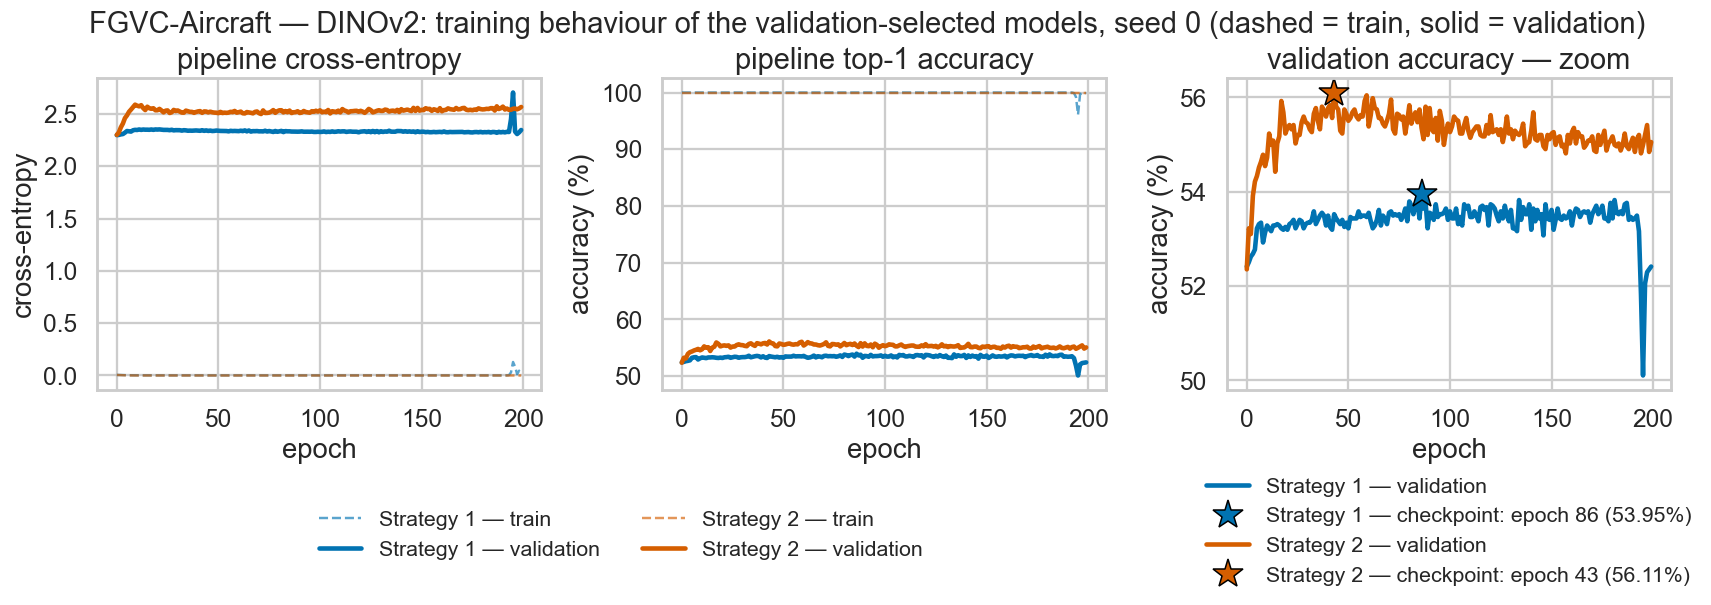

In [3]:
import matplotlib.pyplot as plt

S1_COLOR, S2_COLOR = "#0173B2", "#D55E00"        # colours of the figures of record
CURVES = REPO / "results" / "artifacts" / "curves_stage3"
RUNS3 = pd.read_csv(MET / "runs_stage3.csv")


def _history(ds, enc, head, seed=0):
    with open(CURVES / f"{ds}_{enc}_{head}_seed{seed}.json") as f:
        return json.load(f)


def _checkpoint_epoch(ds, enc, head, seed=0):
    r = RUNS3[(RUNS3["dataset"] == ds) & (RUNS3["encoder"] == enc)
              & (RUNS3["head"] == head) & (RUNS3["seed"] == seed)]
    return int(r["checkpoint_epoch"].iloc[0])


def talk_curves(ds, enc, seed=0):
    # Presentation rendering of the seed-0 training histories of record
    # (results/artifacts/curves_stage3/*.json): the SAME series as the figure of
    # record stage3_curves_<ds>_<enc>.png (Appendix A.5), drawn one dataset at a
    # time, larger fonts, validation emphasised, and the validation-selected
    # checkpoint of record (runs_stage3.csv) marked. Nothing is recomputed.
    plt.rcParams.update({"font.size": 15, "axes.titlesize": 19, "axes.labelsize": 18,
                         "xtick.labelsize": 16, "ytick.labelsize": 16,
                         "legend.fontsize": 14})
    fig, (ax_ce, ax_acc, ax_zoom) = plt.subplots(1, 3, figsize=(16, 5.8))
    for head, color, name in (("fm_s1", S1_COLOR, "Strategy 1"),
                              ("fm_s2", S2_COLOR, "Strategy 2")):
        h, ep = _history(ds, enc, head, seed), _checkpoint_epoch(ds, enc, head, seed)
        assert h["epoch"][ep] == ep
        acc_tr = [100 * v for v in h["train_pipeline_acc"]]
        acc_va = [100 * v for v in h["val_acc"]]
        ax_ce.plot(h["epoch"], h["train_pipeline_ce"], color=color, ls="--", lw=1.6,
                   alpha=0.65, label=f"{name} — train")
        ax_ce.plot(h["epoch"], h["val_ce"], color=color, lw=3.0,
                   label=f"{name} — validation")
        ax_acc.plot(h["epoch"], acc_tr, color=color, ls="--", lw=1.6, alpha=0.65,
                    label=f"{name} — train")
        ax_acc.plot(h["epoch"], acc_va, color=color, lw=3.0, label=f"{name} — validation")
        ax_zoom.plot(h["epoch"], acc_va, color=color, lw=3.0, label=f"{name} — validation")
        ax_zoom.plot([ep], [acc_va[ep]], ls="none", marker="*", ms=20, color=color,
                     mec="black", label=f"{name} — checkpoint: epoch {ep} ({acc_va[ep]:.2f}%)")
    ax_ce.set_title("pipeline cross-entropy")
    ax_ce.set_ylabel("cross-entropy")
    ax_acc.set_title("pipeline top-1 accuracy")
    ax_acc.set_ylabel("accuracy (%)")
    ax_zoom.set_title("validation accuracy — zoom")
    ax_zoom.set_ylabel("accuracy (%)")
    for ax in (ax_ce, ax_acc, ax_zoom):
        ax.set_xlabel("epoch")
    handles, labels = ax_acc.get_legend_handles_labels()      # shared by the two left panels
    ax_zoom.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=False)
    fig.tight_layout()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.36, ax_ce.get_position().y0 - 0.16))
    fig.suptitle(f"{dataset_label(ds)} — {encoder_label(enc, short=True)}: training "
                 f"behaviour of the validation-selected models, seed {seed} "
                 f"(dashed = train, solid = validation)", fontsize=19, y=1.02)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))


talk_curves("fgvc_aircraft", "dinov2_vits14")

### 6b · Training behaviour — DTD / ResNet-18 (validation-selected models, seed 0)

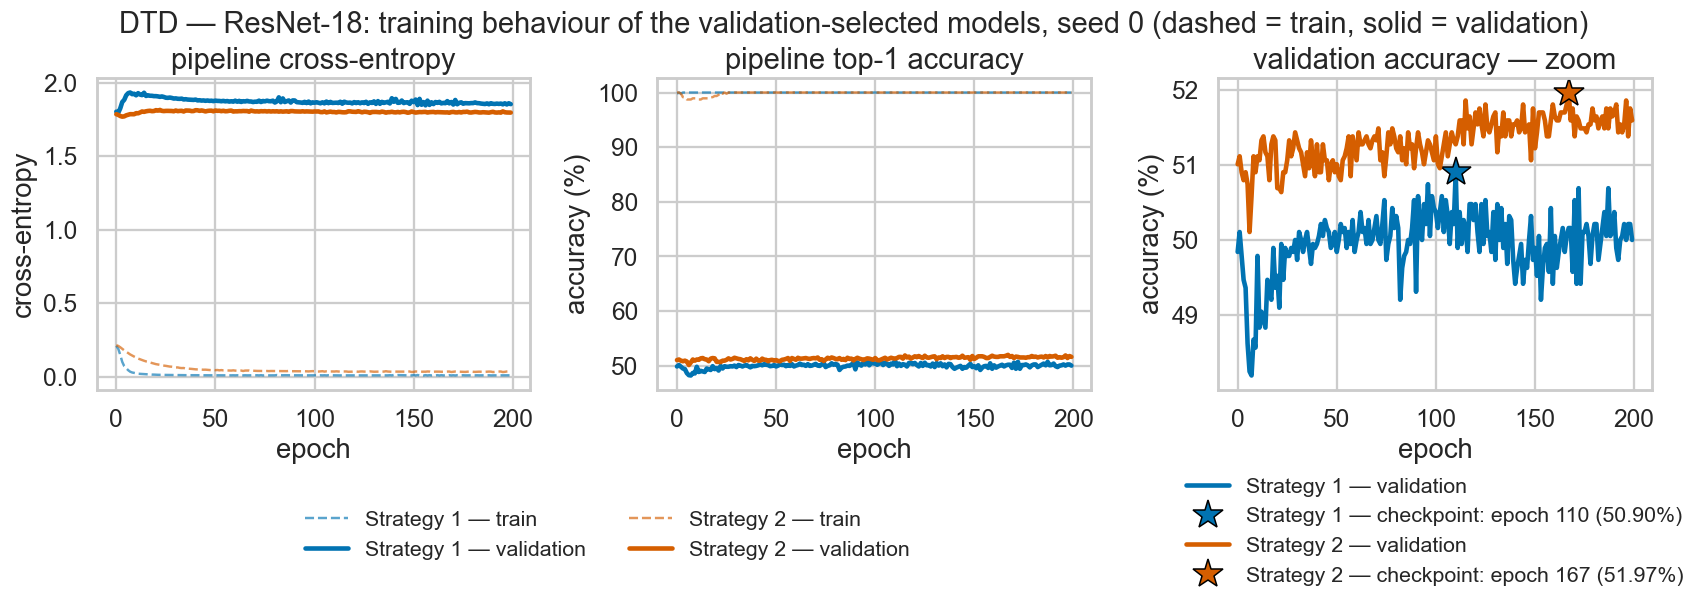

In [4]:
talk_curves("dtd", "resnet18")

- **Both strategies fit the training set completely** — train accuracy ≈ 100%, train cross-entropy ≈ 0 (dashed lines), on both datasets.
- **Validation stays far lower** (≈ 50–56%): at K = 10 the pipeline is data-starved, so the difference between the strategies is a difference in **generalization**, not in fit.
- On FGVC-Aircraft, Strategy 2's validation curve sits above Strategy 1's for essentially the whole run; on DTD the two stay within about a point of each other. ★ marks the best-validation-accuracy checkpoint of record. Strategy-internal diagnostics (displacements, trust-region hit rate, losses): Appendix A.5.

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> שתי האסטרטגיות מגיעות ל-100% על סט האימון; ההבדל ביניהן הוא בהכללה (ולידציה).</p>
<p><b>מונחים בפשטות:</b> <b>Pipeline CE / accuracy</b> — ה-CE והדיוק של הצינור המלא (z → FM → probe קפוא), לא של ה-FM לבד. <b>Train (מקווקו) מול validation (מלא)</b>. <b>הכוכב</b> — ה-epoch של ה-checkpoint שנבחר לפי דיוק ולידציה מרבי (מטבלת הרשומות).</p>
<p><b>מה לומר על הגרפים:</b> פאנל שמאלי ואמצעי — הפער הענק בין train ל-validation (K = 10, מעט מאוד דאטה). הפאנל הימני — זום על הוולידציה: ב-FGVC הכתום (S2) מעל הכחול (S1) לאורך כל הריצה; ב-DTD העקומות קרובות (כנקודה אחת). זה מסביר למה ההפרש ב-DTD בתוך הרעש.</p>
<p><b>שאלה צפויה:</b> "מה הקפיצה בסוף של אסטרטגיה 1 ב-FGVC?" — <b>תשובה:</b> חוסר יציבות סופי (ערכים סופיים, לא NaN) של האובייקטיב הישיר סביב epoch ~195; ה-checkpoint שנבחר (epoch 86 ב-seed 0) הרבה לפני כן, ולכן זה לא משפיע על התוצאה. הקפיצה נראית גם בדיאגנוסטיקת התזוזה בנספח A.5.</p>
<p><b>זמן משוער:</b> ~3 דקות.</p>
</div></details>

## 7 · Feature space — what the FM does to the class structure (joint PCA, seed 0)

**FGVC-Aircraft / DINOv2** — the setting with the +2.50-point gain:

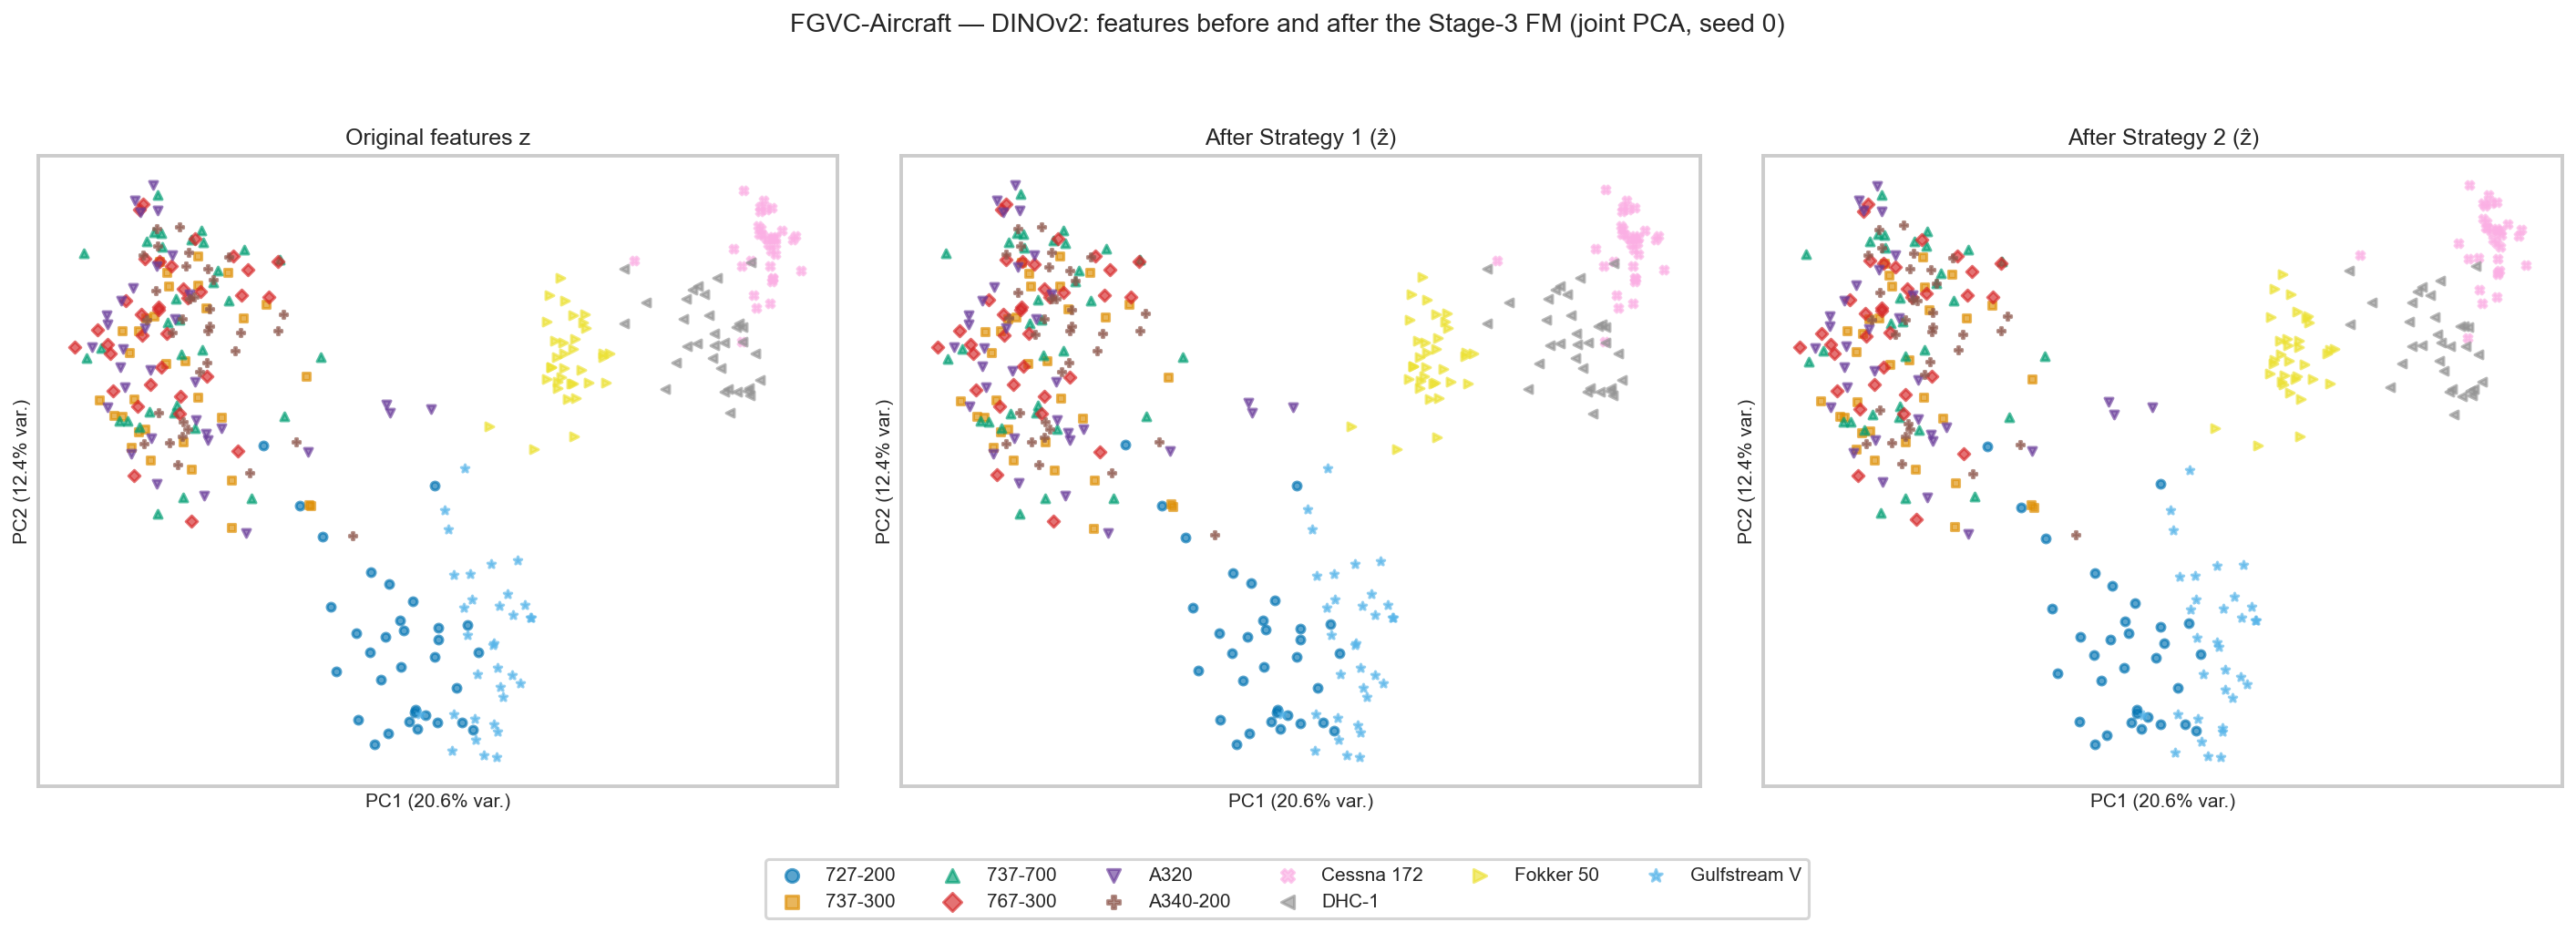

In [5]:
display(Image(str(FIG / "stage3_features_fgvc_aircraft_dinov2_vits14.png"), width=1500))

**DTD / ResNet-18** — the setting with no clear benefit:

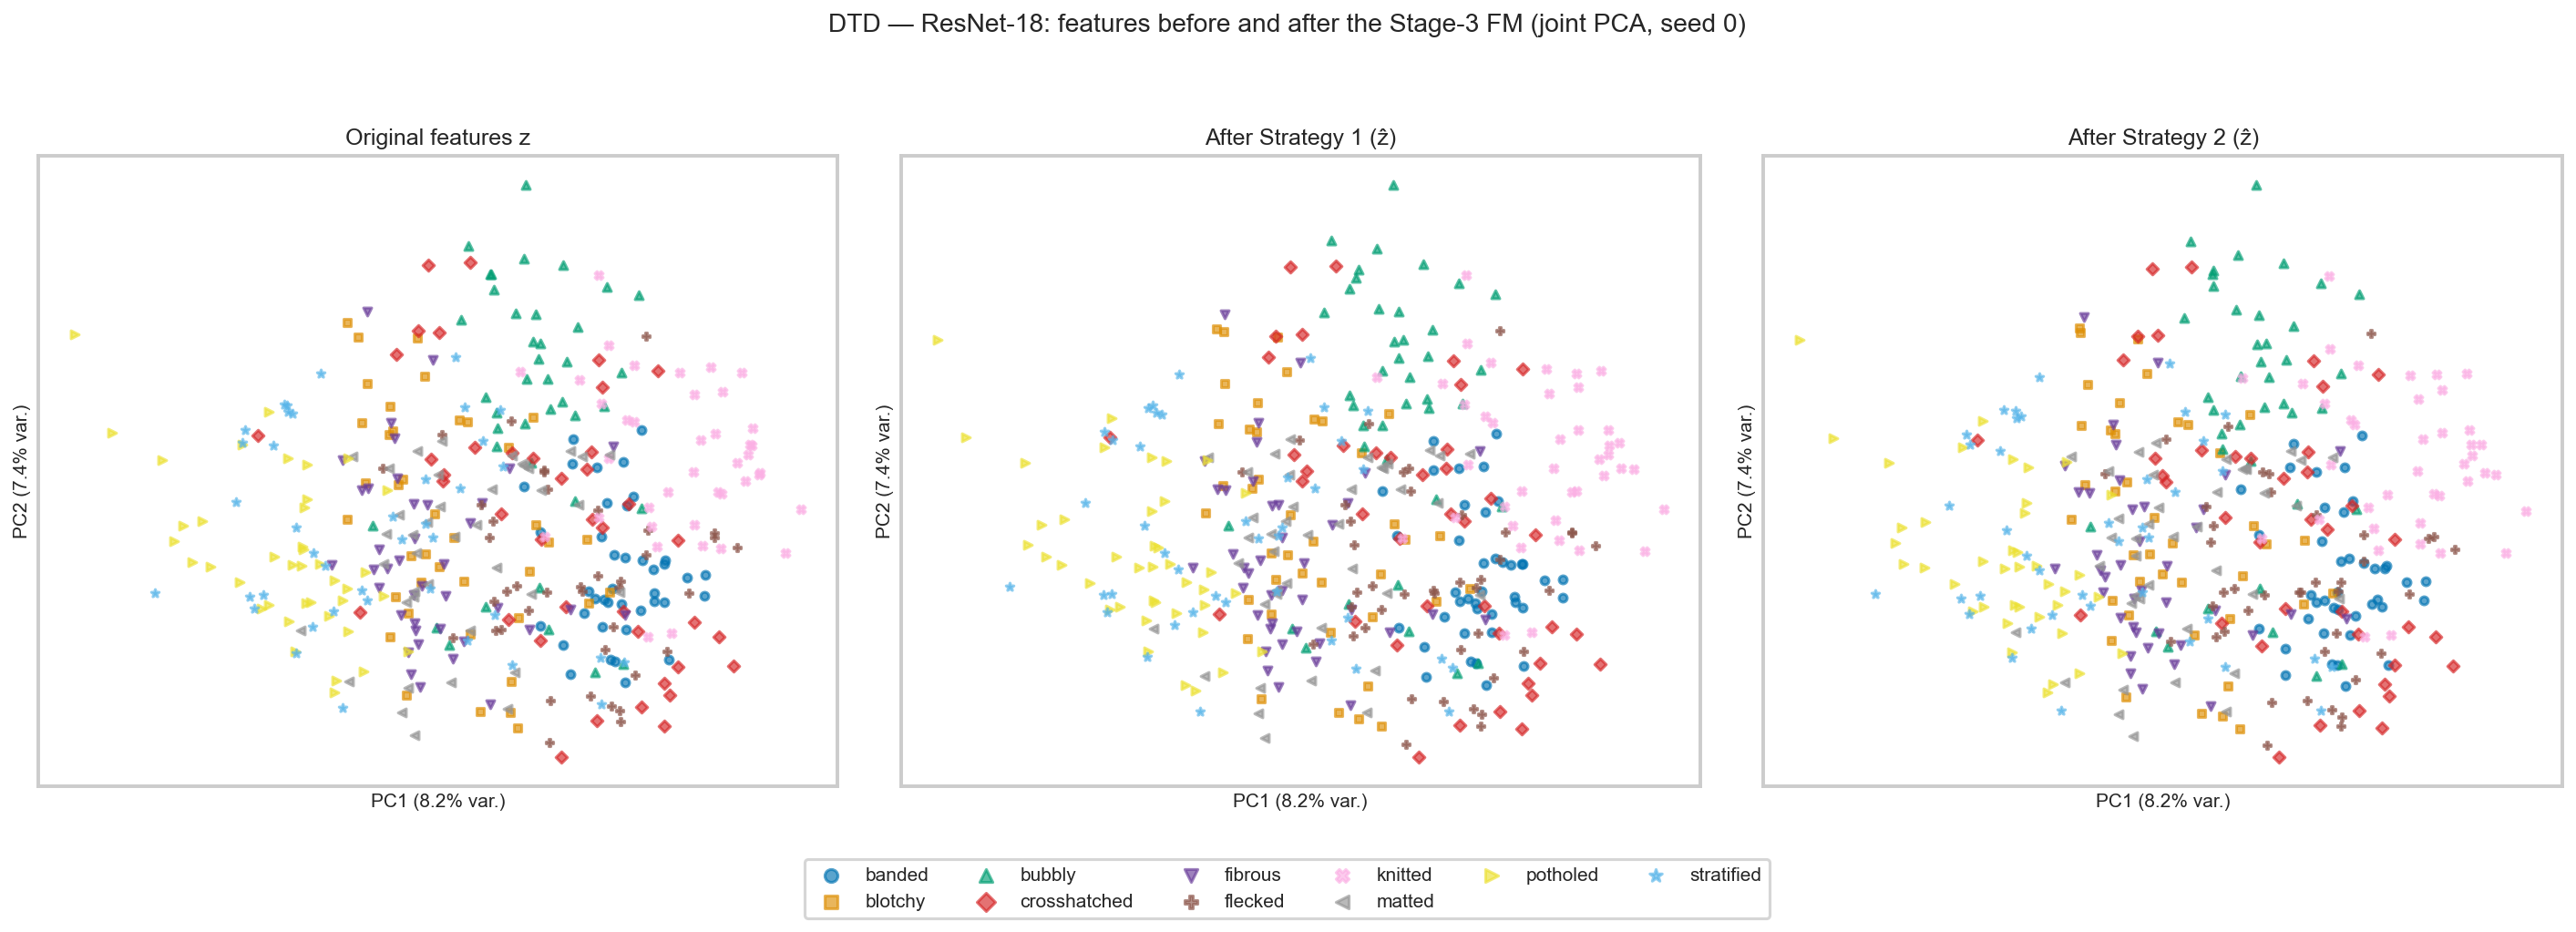

In [6]:
display(Image(str(FIG / "stage3_features_dtd_resnet18.png"), width=1500))

- **Same ten classes, same test examples, same class colours** as Stages 1–2; one PCA fitted **jointly** on $[z,\ \hat{z}_{S1},\ \hat{z}_{S2}]$ in raw space, so the three panels share axes and are directly comparable.
- **The first two PCs change only subtly** — even on FGVC-Aircraft, despite its +2.50-point gain. The transport acts in the full 384-d / 512-d space, along classifier-relevant directions this plane barely captures (it explains 15.6% of the variance on DTD, 33.0% on FGVC).
- Consistent with the measured displacements (≈ 5–13% of the mean feature norm): small, targeted adjustments rather than a visible reorganization. **2-D projections are qualitative only.**

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> התזוזה שה-FM עושה כמעט לא נראית בשני הרכיבים הראשיים — היא קטנה ומכוונת, בכיוונים שרלוונטיים למסווג במרחב הגבוה-ממדי.</p>
<p><b>מונחים בפשטות:</b> <b>PCA</b> — הטלה ליניארית לשני הכיוונים עם השונות הגדולה ביותר. <b>Joint PCA</b> — ההטלה מחושבת פעם אחת על [z, ẑ_S1, ẑ_S2] יחד, ולכן שלושת הפאנלים חולקים צירים ואפשר להשוות ביניהם. <b>Explained variance</b> — כמה מהשונות הכוללת המישור הדו-ממדי תופס: 15.6% ב-DTD (8.2% + 7.4%), 33.0% ב-FGVC (20.6% + 12.4%).</p>
<p><b>מה לומר על הגרפים:</b> אותן 10 מחלקות, אותן דוגמאות ואותם צבעים כמו בשלבים 1–2. להצביע על כך שהמבנה כמעט זהה בשלושת הפאנלים למרות +2.5 נקודות ב-FGVC; להזכיר שהתזוזות הנמדדות הן כ-5–13% מנורמת הפיצ'ר. להתחיל מ-FGVC (הסיפור העיקרי) ולעבור ל-DTD בקצרה.</p>
<p><b>שאלה צפויה:</b> "אם לא רואים שינוי, איך יש שיפור?" — <b>תשובה:</b> המישור מסביר רק 33% מהשונות ב-FGVC; המסווג פועל על 384 ממדים, ותזוזה קטנה בכיוון שמשנה את הלוגיטים לא חייבת להיות נראית ב-PC1/PC2. זו אבחנה איכותית בלבד — לא ראיה כמותית.</p>
<p><b>זמן משוער:</b> ~3 דקות.</p>
</div></details>

## 8 · Conclusions

1. **Strategy 2 is the best method on FGVC-Aircraft / DINOv2:** +2.50 ± 0.50 points over the pinned probe, positive on 3/3 seeds (+2.76 / +1.92 / +2.82); Strategy 1 gains +0.88 ± 0.23 (3/3).
2. **DTD / ResNet-18 shows no clear improvement:** Strategy 2 +0.16 ± 0.45 (2/3 seeds), Strategy 1 −0.69 ± 0.70 (1/3) — everything within the seed spread at this operating point.
3. **The indirect strategy beats the direct one on both datasets** (FGVC +2.50 vs +0.88; DTD +0.16 vs −0.69; the same ordering appeared on the validation sweeps before test was opened) — but the component responsible is **not isolated**.

Strategy 2 differs from Strategy 1 through several components at once: the source-centred trust region, lowest-CE (monotone) target selection, classifier-guided target construction, and standard path-regression training.

Both strategies memorize the training set, so the gap lies in what each objective does *off* the training points — and everything that differs there pushes Strategy 2 toward conservatism. Which component matters is an open question this experiment does not answer.

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> שלוש מסקנות — S2 הכי טוב ב-FGVC (+2.50 ± 0.50, 3/3 seeds); אין שיפור ברור ב-DTD; והשיטה העקיפה מנצחת את הישירה בשני הדאטהסטים — אבל בלי לבודד איזה רכיב אחראי.</p>
<p><b>מונחים בפשטות:</b> <b>Direct vs indirect</b> — S1 מקבל גרדיאנט CE ישירות; S2 רק דרך מטרות. <b>Path regression</b> — אימון על כל הקו בין z ל-ẑ′ ולא רק על נקודת הקצה. <b>Conservatism</b> — מגבלות קשיחות על גודל התזוזה ועל טיב המטרה (אזור אמון + קבלה מונוטונית).</p>
<p><b>מה לומר:</b> לקרוא את שלוש המסקנות עם המספרים. בפסקאות — להדגיש ש-S2 שונה מ-S1 בכמה רכיבים <u>בבת אחת</u>, ולכן אי אפשר לומר איזה מהם אחראי; שתי האסטרטגיות משננות את סט האימון, ולכן ההבדל הוא במה שקורה מחוץ לנקודות האימון. הדמיון לתוצאת שלב 2 (path supervision מכליל טוב יותר מ-endpoint) הוא דפוס חוזר, לא מנגנון שבודד.</p>
<p><b>שאלה צפויה:</b> "איזה רכיב של S2 אחראי לשיפור?" — <b>תשובה:</b> לא ידוע מהניסוי הזה; זה דורש אבלציה (למשל S1 עם אזור אמון קשיח, או S2 בלי בחירה מונוטונית). זו הצעה מפורשת לעבודת המשך.</p>
<p><b>זמן משוער:</b> ~3 דקות.</p>
</div></details>

## 9 · Limitations and takeaway

- **n = 3 subset seeds** — spreads are sample standard deviations; no significance claims (the spread measures subset sampling only; probe-init and FM-init are fixed).
- **Seed 0 is partly a development run** — hyperparameters were selected on its validation split; the 3-seed mean is a summary, not an independent confirmatory estimate.
- **One K (10), one T (4), one encoder per dataset** — by the spec's own scoping; conclusions are about this operating point.
- **2-D PCA is qualitative** — the joint plane explains 15.6% (DTD) / 33.0% (FGVC-Aircraft) of the variance. Full limitations list: Appendix A.8.

> **Takeaway:** Flow Matching before a frozen classifier is not universally beneficial, but conservative classifier-guided targets produce a consistent improvement on the fine-grained FGVC-Aircraft setting.

<details><summary><b>Speaker notes · הערות למרצה (עברית)</b></summary>
<div dir="rtl" style="text-align:right; line-height:1.65; margin:0.6em 1em;">
<p><b>הנקודה המרכזית:</b> המגבלות מגדירות מה מותר להסיק — ואז המסר הסופי, מילה במילה.</p>
<p><b>מונחים בפשטות:</b> <b>Sample std</b> — סטיית תקן מדגמית (חלוקה ב-n−1). <b>Operating point</b> — הצירוף הספציפי של K, T, encoder ומסווג. <b>Development run</b> — ריצה ששימשה גם לבחירת היפר-פרמטרים ולכן אינה אימות בלתי-תלוי.</p>
<p><b>מה לומר:</b> לעבור על ארבעת הבולטים בקצרה ולסיים במשפט המסר. לא להוסיף טענות מעבר לו: "לא תמיד מועיל, אבל מטרות שמרניות מונחות-מסווג נותנות שיפור עקבי ב-FGVC-Aircraft".</p>
<p><b>שאלה צפויה:</b> "מה הייתם עושים עם עוד זמן?" — <b>תשובה:</b> יותר seeds (להעריך את השונות), אבלציה של רכיבי S2 ושל רדיוס אזור האמון α = 0.1 (שהיה "רווי" — כמעט 100% מהמטרות על שפת הכדור, נספח A.5), ו-K / T נוספים.</p>
<p><b>זמן משוער:</b> ~2 דקות.</p>
</div></details>

# Appendix — full evidence and reproducibility (reference material, not presented)

Moved here from the talk body; `stage3_presentation.ipynb` remains the complete scientific report.

- **A.1** environment and complete training configuration, including the failure / fallback policy
- **A.2** the two guards, re-executed: exact identity at initialization; pinned-probe reproduction audit
- **A.3** tables of record: main table with its full caption; the λ-ablation pair; the full seed-0 validation sweep
- **A.4** per-seed paired deltas
- **A.5** figures of record and strategy-internal diagnostics
- **A.6** checkpoint placement and displacement
- **A.7** optional joint FM + classifier extension, with its classifier-only control
- **A.8** full limitations, deviations from the specification, artifact paths and reproduction commands

## A.1 · Environment and complete training configuration

In [7]:
with open(REPO / "results" / "runtime_summary.json") as f:
    print("Runtime:", json.dumps(json.load(f), indent=2))

s3 = cfg["stage3"]
print("\nSettings:", s3["settings"], "| K =", s3["k_shot"], "| T =", s3["T"],
      "| feature space:", s3["feature_space"])
print("Training policy:", json.dumps(s3["training"], indent=2))
print("S1 lambda grid:", s3["strategy1"]["lambda_grid"],
      "| S2 grid: beta", s3["strategy2"]["beta_grid"], "x m", s3["strategy2"]["m_grid"],
      "| trust region alpha =", s3["strategy2"]["alpha_trust_region"])

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Settings: [['dtd', 'resnet18'], ['fgvc_aircraft', 'dinov2_vits14']] | K = 10 | T = 4 | feature space: raw
Training policy: {
  "optimizer": "adamw",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "epochs": 200,
  "checkpoint_selection": "highest_validation_accuracy",
  "fallbacks": [
    "grad_clip_1.0",
    "lr_3e-4",
    "input_standardization"
  ]
}
S1 lambda grid: [0, 1, 10, 100] | S2 grid: beta [0.25, 0.5, 1.0] x m [1, 3] | trust region alpha = 0.1


**Provenance of every choice.** The FM operates in **raw feature space** — the probe was trained on raw features ($s = Wz + b$, norms ≈ 10–40), so normalizing on entry would break the required identity-at-initialization (note the deliberate contrast with Stage 2, where the downstream classifier was cosine-based and the FM therefore lived on the unit sphere: *the FM operates in the space its downstream classifier acts in*). The velocity network and Euler procedure are the Stage-2 design, as the spec instructs (MLP $d{+}1 \to 512 \to 512 \to d$, SiLU, scalar $t$ concatenated; $\hat{z}_{k+1} = \hat{z}_k + \frac{1}{T}v_\theta(\hat{z}_k, k/T)$). **Identity initialization is exact**: the final velocity layer (weight *and* bias) starts at zero, so $\hat{z} = z$ bit-for-bit — asserted, not assumed (A.2).

**Training policy (uniform for both strategies, fixed a priori):** AdamW, lr $10^{-3}$, weight decay $10^{-4}$, batch 64, exactly 200 epochs with the **best-validation-accuracy checkpoint** retained (ties → lowest validation CE → earliest epoch). Validation-based selection is deliberate and symmetric: the baseline probe itself was selected the same way in Stage 1, and both strategies expose the identical full-pipeline validation curve. Failure policy (objective trigger — NaN/Inf loss only): restart with the next pre-registered fallback (cumulative ladder: grad-clip 1.0 → lr 3e-4 → internal input standardization, which preserves the exact identity); finite late deterioration is absorbed by checkpointing; exhausted ladder ⇒ run marked failed. **Hyperparameters were selected per dataset on seed-0 validation only**; winners applied unchanged to seeds 1–2; the **test split stayed sealed** during all training and selection, and was evaluated in **one final pass per pre-registered phase** (the mandatory grid; then the optional extension), each over its already-locked checkpoints. Disclosed: seed 0 is therefore partly a development run, and the 3-seed mean is a summary, not an independent confirmatory estimate.

## A.2 · The two guards, re-executed

**Two guards, train/validation data only (the test set stayed sealed):**

1. **Exact identity at initialization** — transported features **bit-exact equal** to the inputs, logits equal, predictions identical between the pipeline and the direct probe. Stronger than accuracy equality (two systems can share accuracy while disagreeing on many predictions). The first cell below re-executes it.
2. **Pinned-probe reproduction** — the probe is retrained with the identical Stage-1 recipe per (dataset, subset seed), its **validation** accuracy audited against `runs.csv` (|diff| < 0.25 pts; the run log shows 0.000 pts and identical best epochs on all six probes), and the weights pinned so every method receives the same frozen classifier. Δ is computed against **this exact pinned probe** — `runs.csv` serves as a reproduction audit only; the second cell below displays the recorded accuracies reproducing the published values within $10^{-12}$ (test compared post-hoc at the final pass).

In [8]:
import torch

from src.stage3 import Stage3FM, identity_guard, load_pinned_probe
from src.embeddings import load_features

mdir = REPO / "results" / "artifacts" / "stage3_models"
k = f"{cfg['stage3']['k_shot']}shot"
print("Exact-identity guard (re-executed live, validation data only):")
for ds, enc in cfg["stage3"]["settings"]:
    probe = load_pinned_probe(mdir / f"probe_{ds}_{enc}_{k}_seed0.pt")
    fval = load_features(ds, "val", enc)
    fm0 = Stage3FM(probe, fval["dim"], seed=cfg["stage3"]["fm_init_seed"])
    identity_guard(fm0, fval["features"][:256])
    print(f"  [OK] {ds} / {enc}: transported features bit-exact, logits and "
          f"predictions identical to the direct probe")

Exact-identity guard (re-executed live, validation data only):


  [OK] dtd / resnet18: transported features bit-exact, logits and predictions identical to the direct probe
  [OK] fgvc_aircraft / dinov2_vits14: transported features bit-exact, logits and predictions identical to the direct probe


In [9]:
# Probe-reproduction audit, displayed from the artifacts of record: the pinned
# probes' validation and test accuracies against the published Stage-1 values.
r1 = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")
r3 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage3.csv")
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for seed in cfg["stage3"]["subset_seeds"]:
        pin = r3[(r3["dataset"] == ds) & (r3["encoder"] == enc)
                 & (r3["head"] == "pinned_probe") & (r3["seed"] == seed)].iloc[0]
        ref = r1[(r1["dataset"] == ds) & (r1["encoder"] == enc)
                 & (r1["head"] == "linear_probe") & (r1["k_shot"] == k)
                 & (r1["seed"] == seed)].iloc[0]
        rows.append({"dataset": ds, "seed": seed,
                     "pinned val (%)": round(100 * pin["val_acc"], 4),
                     "Stage-1 val (%)": round(100 * ref["val_acc"], 4),
                     "pinned test (%)": round(100 * pin["test_acc"], 4),
                     "Stage-1 test (%)": round(100 * ref["test_acc"], 4),
                     "within 1e-12": bool(np.isclose(pin["val_acc"], ref["val_acc"],
                                                     rtol=0, atol=1e-12)
                                          and np.isclose(pin["test_acc"],
                                                         ref["test_acc"],
                                                         rtol=0, atol=1e-12))})
audit = pd.DataFrame(rows)
assert audit["within 1e-12"].all()
print("Pinned-probe reproduction audit — recorded validation and test accuracies "
      "reproduce the published Stage-1 values within 1e-12 on all six probes "
      "(equal accuracies do not by themselves prove identical weights; the "
      "feature-level bit-exactness claim belongs to the identity guard above):")
display(audit)

Pinned-probe reproduction audit — recorded validation and test accuracies reproduce the published Stage-1 values within 1e-12 on all six probes (equal accuracies do not by themselves prove identical weights; the feature-level bit-exactness claim belongs to the identity guard above):


,dataset,seed,pinned val (%),Stage-1 val (%),pinned test (%),Stage-1 test (%),within 1e-12
0,dtd,0,50.74,50.74,53.99,53.99,True
1,dtd,1,54.10,54.10,54.47,54.47,True
2,dtd,2,51.33,51.33,54.47,54.47,True
3,fgvc_aircraft,0,52.51,52.51,52.12,52.12,True
4,fgvc_aircraft,1,51.43,51.43,51.52,51.52,True
5,fgvc_aircraft,2,49.35,49.35,50.26,50.26,True


## A.3 · Tables of record

Every number is generated programmatically from `results/metrics/` and re-derived by the repro check; raw per-run accuracies in `results/metrics/raw/stage3_*.npy`, the per-run table in `runs_stage3.csv`. Δ is **paired per seed** against the exact pinned probe of that seed.

### A.3.1 Main comparison (the spec's required table, with its full caption)

In [10]:
display(Markdown((REPO / "results" / "metrics" / "stage3_main_table.md")
                 .read_text(encoding="utf-8")))

| Dataset / encoder | Head | Top-1 (%) | Δ vs pinned probe (pts, paired) |
|---|---|---|---|
| DTD / ResNet-18 | Pinned Stage-1 probe (baseline) | 54.31 ± 0.28 | — |
| DTD / ResNet-18 | Strategy 1 — rolled-out CE training (λ = 1) | 53.62 ± 0.89 | -0.69 ± 0.70 (1/3 seeds > 0) |
| DTD / ResNet-18 | Strategy 2 — classifier-guided targets (β = 0.25, m = 1) | 54.47 ± 0.70 | +0.16 ± 0.45 (2/3 seeds > 0) |
| FGVC-Aircraft / DINOv2 | Pinned Stage-1 probe (baseline) | 51.30 ± 0.95 | — |
| FGVC-Aircraft / DINOv2 | Strategy 1 — rolled-out CE training (λ = 1) | 52.18 ± 1.11 | +0.88 ± 0.23 (3/3 seeds > 0) |
| FGVC-Aircraft / DINOv2 | Strategy 2 — classifier-guided targets (β = 0.5, m = 3) | 53.80 ± 0.95 | +2.50 ± 0.50 (3/3 seeds > 0) |

Top-1 accuracy (%) on the complete official test split, K = 10, T = 4; mean ± sample std over the 3 subset seeds. Δ is **paired per seed** against the exact pinned probe of that seed — the identical frozen classifier inside the pipeline (the pipeline at initialization equals it exactly, by the zero-velocity init). Hyperparameters (λ; β, m) were selected per dataset on **seed-0 validation** only; seed 0 is therefore partly a development run, and the 3-seed mean is a summary, not an independent confirmatory estimate. n = 3 — no significance claims.

### A.3.2 Strategy 1 — with vs without the displacement regularizer (pre-registered pair)

In [11]:
display(Markdown((REPO / "results" / "metrics" / "stage3_lambda_ablation_table.md")
                 .read_text(encoding="utf-8")))

| Dataset / encoder | Variant | Top-1 (%) | Δ vs pinned probe (pts) |
|---|---|---|---|
| DTD / ResNet-18 | validation-selected λ (λ = 1) | 53.62 ± 0.89 | -0.69 ± 0.70 |
| DTD / ResNet-18 | λ = 0 | 53.51 ± 1.25 | -0.80 ± 0.98 |
| FGVC-Aircraft / DINOv2 | validation-selected λ (λ = 1) | 52.18 ± 1.11 | +0.88 ± 0.23 |
| FGVC-Aircraft / DINOv2 | λ = 0 | 51.80 ± 0.88 | +0.50 ± 0.95 |

Pre-registered pair: the validation winner AND λ = 0 both receive a test read-out, so the with/without-regularization comparison involves no post-hoc choice.

### A.3.3 Selection transparency — the full seed-0 validation sweep

Everything the winners were chosen from, so the selection involves no undisclosed freedom. Test was untouched during selection.

In [12]:
display(Markdown((REPO / "results" / "metrics" / "stage3_sweep_table.md")
                 .read_text(encoding="utf-8")))

| Dataset | Strategy | Configuration | Val top-1 (%) | Checkpoint epoch | Fallback |
|---|---|---|---|---|---|
| DTD | S1 | lam=0 | 49.79 | 1 | 0 |
| DTD | S1 | lam=1 | 50.90 | 110 | 0 |
| DTD | S1 | lam=10 | 50.59 | 103 | 0 |
| DTD | S1 | lam=100 | 50.74 | 1 | 0 |
| DTD | S2 | beta=0.25,m=1 | 51.97 | 167 | 0 |
| DTD | S2 | beta=0.25,m=3 | 51.76 | 156 | 0 |
| DTD | S2 | beta=0.5,m=1 | 51.86 | 157 | 0 |
| DTD | S2 | beta=0.5,m=3 | 51.81 | 152 | 0 |
| DTD | S2 | beta=1.0,m=1 | 51.91 | 145 | 0 |
| DTD | S2 | beta=1.0,m=3 | 51.70 | 10 | 0 |
| FGVC-Aircraft | S1 | lam=0 | 53.74 | 16 | 0 |
| FGVC-Aircraft | S1 | lam=1 | 53.95 | 86 | 0 |
| FGVC-Aircraft | S1 | lam=10 | 53.05 | 184 | 0 |
| FGVC-Aircraft | S1 | lam=100 | 52.72 | 156 | 0 |
| FGVC-Aircraft | S2 | beta=0.25,m=1 | 55.06 | 42 | 0 |
| FGVC-Aircraft | S2 | beta=0.25,m=3 | 55.78 | 17 | 0 |
| FGVC-Aircraft | S2 | beta=0.5,m=1 | 55.54 | 62 | 0 |
| FGVC-Aircraft | S2 | beta=0.5,m=3 | 56.11 | 43 | 0 |
| FGVC-Aircraft | S2 | beta=1.0,m=1 | 55.78 | 34 | 0 |
| FGVC-Aircraft | S2 | beta=1.0,m=3 | 56.11 | 17 | 0 |

Seed-0 **validation** accuracy of the full pipeline per swept configuration (test untouched during selection). Winners per dataset by highest validation accuracy (ties → lowest validation CE → grid order). Fallback level 0 = the default recipe (ADR 0008 §7).

## A.4 · Per-seed paired deltas

In [13]:
from src.visualize import dataset_label, encoder_label

HEAD_SHOW = {"fm_s1": "Strategy 1", "fm_s1_lambda0": "Strategy 1, λ=0",
             "fm_s2": "Strategy 2"}
r3 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage3.csv")
ok = r3[r3["status"] == "ok"]
print("Per-seed paired deltas (percentage points), the quantity every claim rests on:")
t = (ok[ok["head"] != "pinned_probe"]
     .assign(setting=lambda d: d["dataset"].map(dataset_label) + " / "
             + d["encoder"].map(lambda e: encoder_label(e, short=True)),
             method=lambda d: d["head"].map(HEAD_SHOW),
             delta_pts=lambda d: (100 * d["delta_acc"]).round(2))
     .pivot_table(index=["setting", "method"], columns="seed", values="delta_pts"))
display(t)

Per-seed paired deltas (percentage points), the quantity every claim rests on:


seed                                       0     1     2
setting                method                           
DTD / ResNet-18        Strategy 1      -1.17 -1.01  0.11
                       Strategy 1, λ=0 -1.91 -0.37 -0.11
                       Strategy 2      -0.27  0.11  0.64
FGVC-Aircraft / DINOv2 Strategy 1       1.14  0.72  0.78
                       Strategy 1, λ=0  0.63 -0.51  1.38
                       Strategy 2       2.76  1.92  2.82

## A.5 · Figures of record and strategy-internal diagnostics

**End-to-end curves of record** (the talk's Section 6 re-renders exactly these seed-0 histories): the full-pipeline cross-entropy and top-1 accuracy of $z \to \mathrm{FM} \to$ frozen probe, on train and validation, every epoch. Dashed = train, solid = validation; blue = Strategy 1, orange = Strategy 2.

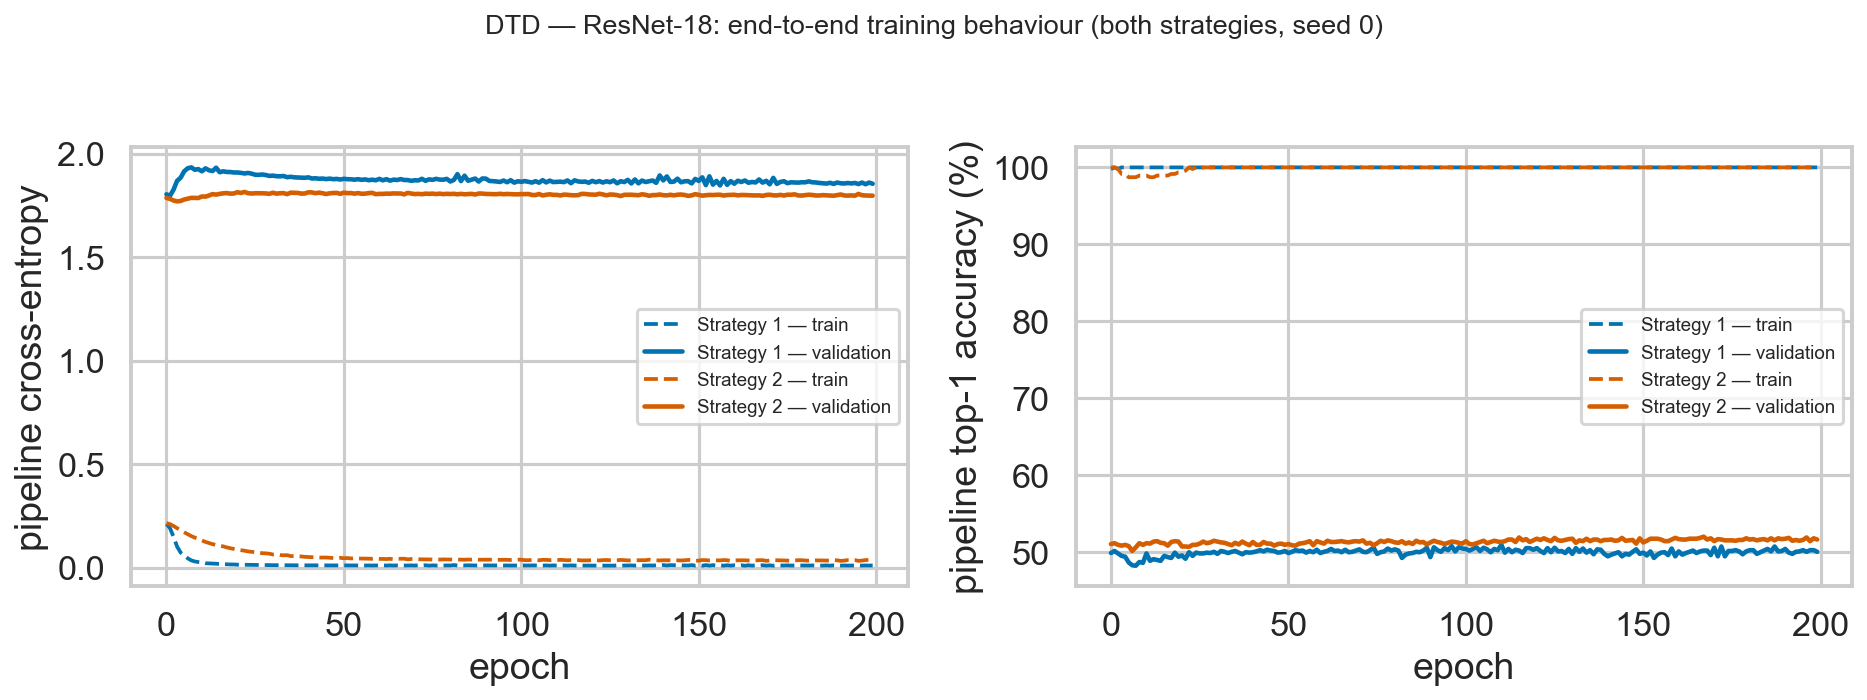

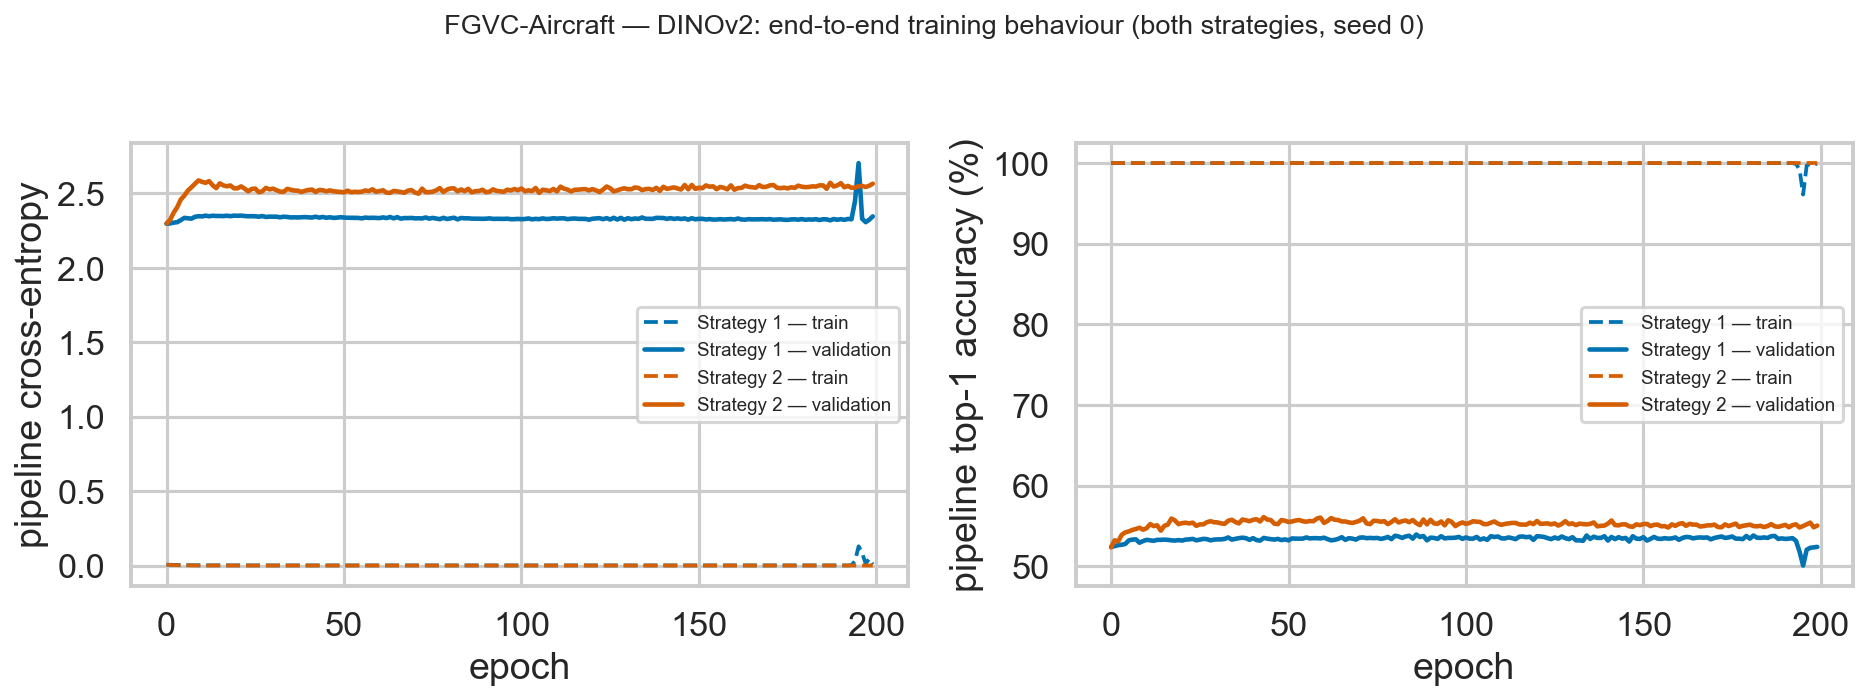

In [14]:
for ds, enc in cfg["stage3"]["settings"]:
    p = REPO / "results" / "figures" / f"stage3_curves_{ds}_{enc}.png"
    if p.exists():
        display(Image(str(p), width=980))

**Strategy-internal diagnostics — separate axes, deliberately.** These quantities measure different things and are never drawn on a shared axis: Strategy 1's relative displacement penalty; Strategy 2's FM-regression loss; Strategy 2's target construction (CE of the unprojected snapshot output — diagnostic only; CE at the projected $u_0$; CE at the selected target) with the **trust-region hit rate** (fraction of samples whose target sits on the boundary $\lVert\hat{z}' - z\rVert = \rho$) on the twin axis; and the mean displacements. Note the S2 phase-1 values describe the *pre-update* snapshot of each epoch, while its validation values describe the post-update model — a one-phase offset inherent to the two-phase scheme.

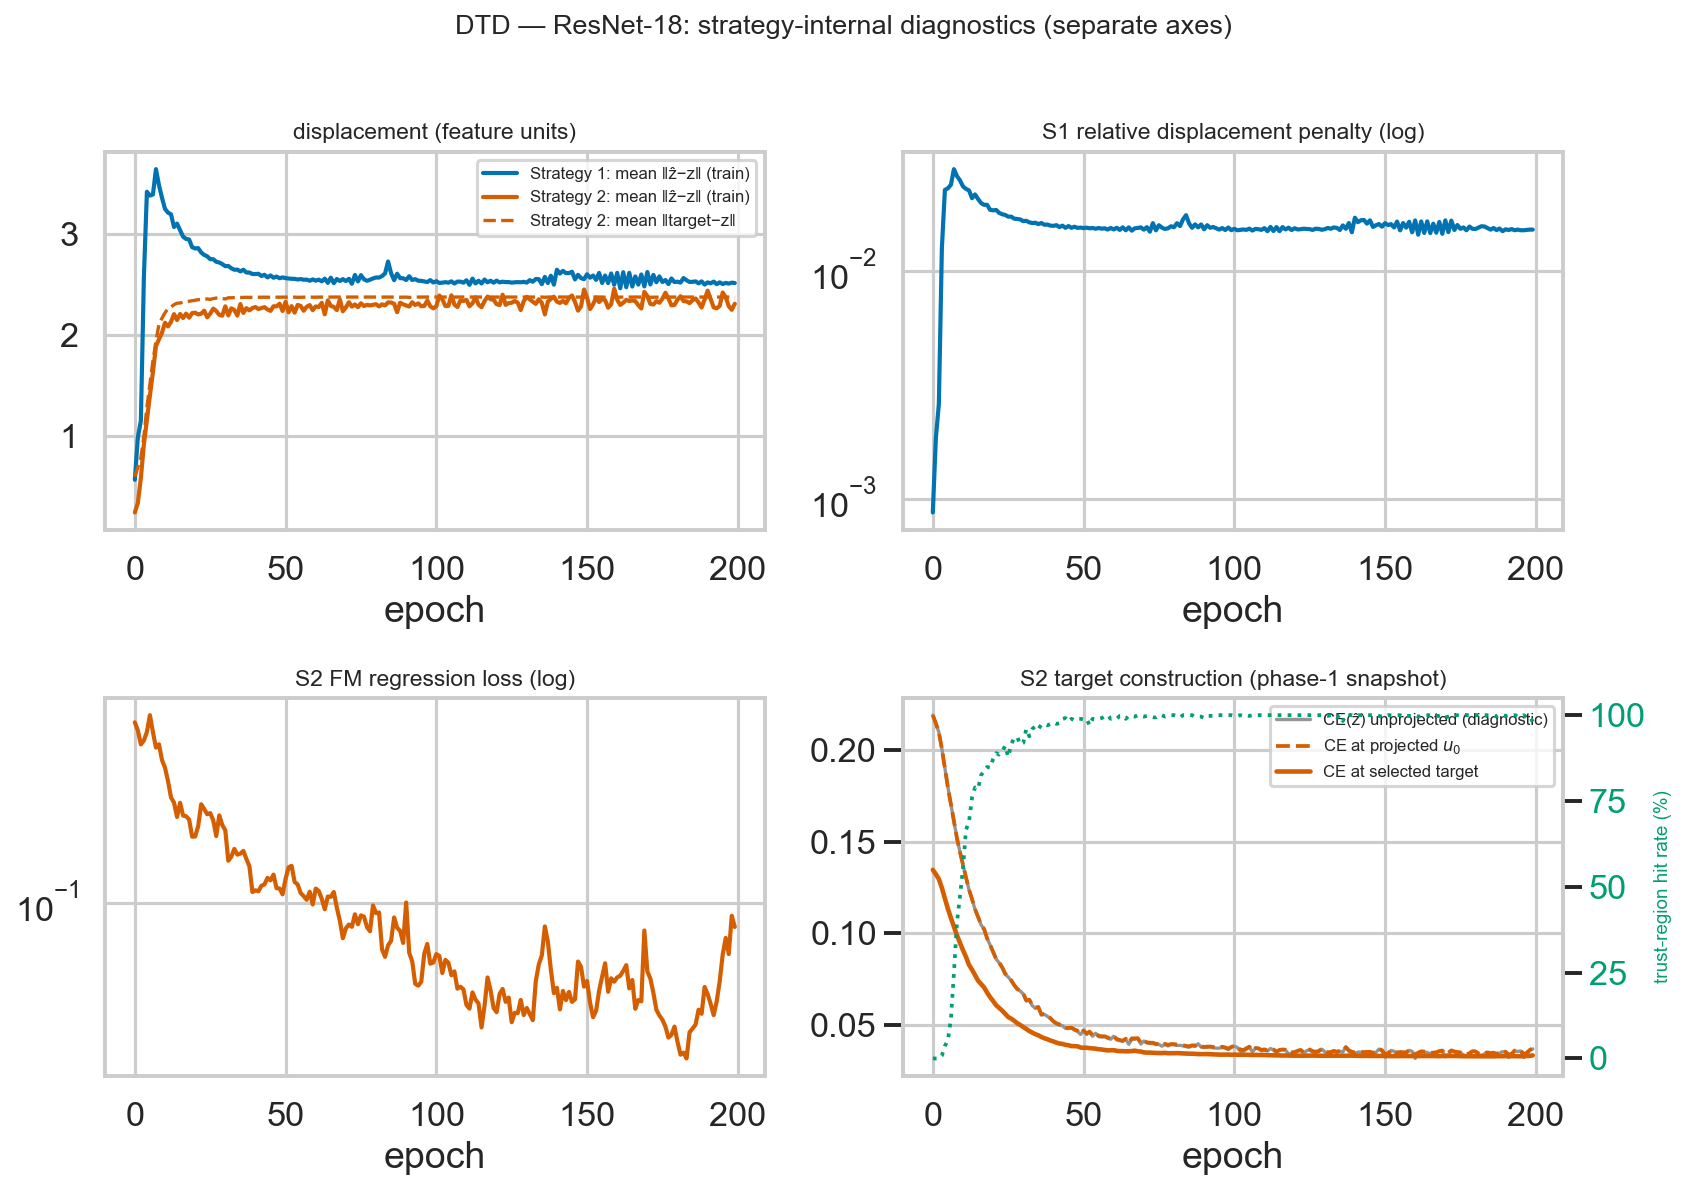

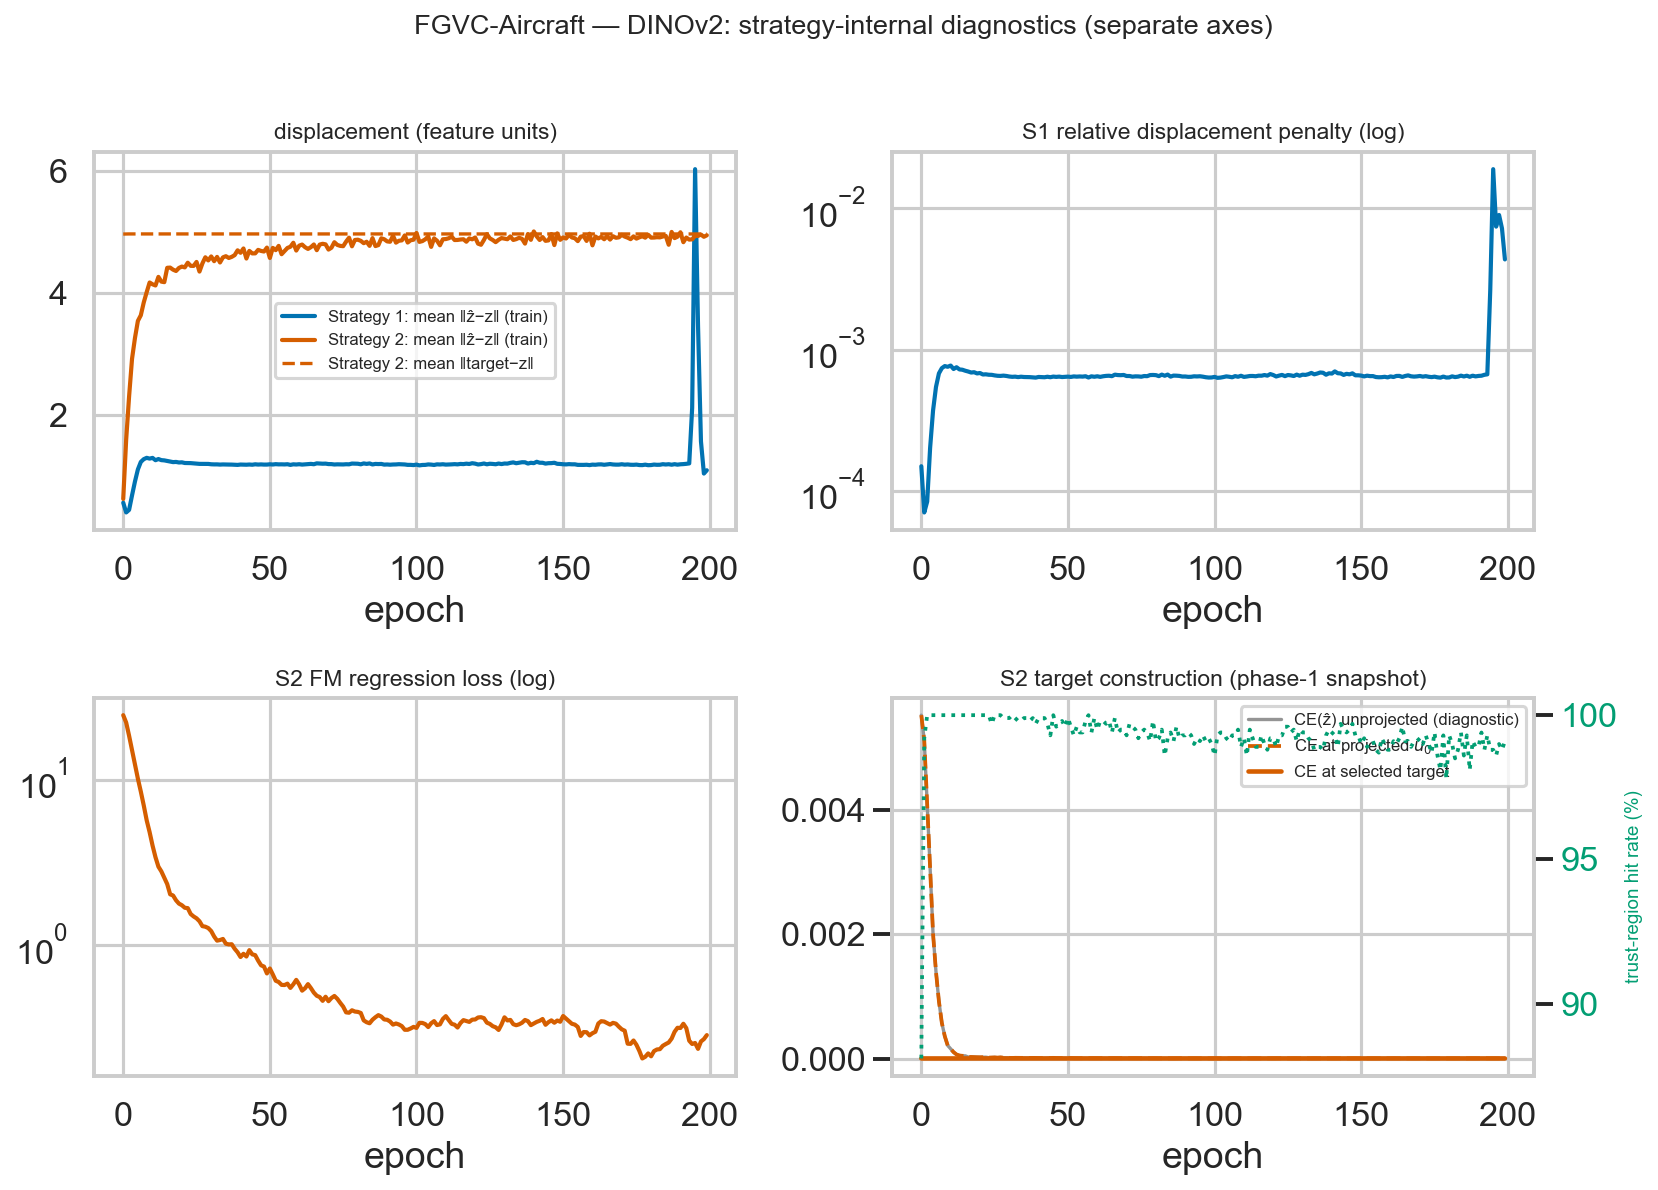

In [15]:
for ds, enc in cfg["stage3"]["settings"]:
    p = REPO / "results" / "figures" / f"stage3_diag_{ds}_{enc}.png"
    if p.exists():
        display(Image(str(p), width=1150))

## A.6 · Checkpoint placement and displacement

In [16]:
import json as _json

from src.visualize import dataset_label

HEADS = {"fm_s1": "Strategy 1", "fm_s2": "Strategy 2"}
cdir = REPO / "results" / "artifacts" / "curves_stage3"
r3 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage3.csv")
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for head in ("fm_s1", "fm_s2"):
        for seed in cfg["stage3"]["subset_seeds"]:
            h = _json.load(open(cdir / f"{ds}_{enc}_{head}_seed{seed}.json"))
            # checkpoint epoch from the table of record (runs_stage3.csv), which
            # applies the full tie-break rule (val acc -> val CE -> earliest)
            ep = int(r3[(r3["dataset"] == ds) & (r3["encoder"] == enc)
                        & (r3["head"] == head)
                        & (r3["seed"] == seed)]["checkpoint_epoch"].iloc[0])
            rows.append({"dataset": dataset_label(ds), "strategy": HEADS[head],
                         "seed": seed,
                         "best val acc (%)": round(100 * max(h["val_acc"]), 2),
                         "checkpoint epoch": ep,
                         "‖ẑ−z‖ at checkpoint": round(h["mean_disp"][ep], 3)})
print("Checkpoint placement and displacement — the two mandatory strategies' "
      "final models (λ=0 and the optional-extension models are tabulated in "
      "A.3.2 / A.7):")
display(pd.DataFrame(rows))
failed = sorted(cdir.glob("*_failed_lv*.json"))
print(f"Failed training attempts (partial curves saved): {len(failed)}"
      + (" — " + ", ".join(p.name for p in failed) if failed else
         " — no NaN/Inf occurred; every run completed at fallback level 0 "
         "(the default recipe)."))

Checkpoint placement and displacement — the two mandatory strategies' final models (λ=0 and the optional-extension models are tabulated in A.3.2 / A.7):


,dataset,strategy,seed,best val acc (%),checkpoint epoch,‖ẑ−z‖ at checkpoint
0,DTD,Strategy 1,0,50.90,110,2.54
1,DTD,Strategy 1,1,54.57,79,2.55
2,DTD,Strategy 1,2,51.22,179,3.15
3,DTD,Strategy 2,0,51.97,167,2.29
4,DTD,Strategy 2,1,55.21,185,2.34
5,DTD,Strategy 2,2,52.82,175,2.28
6,FGVC-Aircraft,Strategy 1,0,53.95,86,1.19
7,FGVC-Aircraft,Strategy 1,1,52.45,117,1.14
8,FGVC-Aircraft,Strategy 1,2,50.29,36,1.24
9,FGVC-Aircraft,Strategy 2,0,56.11,43,4.69


Failed training attempts (partial curves saved): 0 — no NaN/Inf occurred; every run completed at fallback level 0 (the default recipe).


## A.7 · Optional extension — unfreezing the classifier, with its attribution control

Run only after the mandatory comparison was complete (ADR 0008 §9): joint FM + classifier fine-tuning (classifier lr 1e-4, FM lr 1e-3, same policy), against the **classifier-only continued-training control** — the pinned probe trained further *alone* with the same budget.

In [17]:
display(Markdown((REPO / "results" / "metrics" / "stage3_joint_table.md")
                 .read_text(encoding="utf-8")))

| Dataset / encoder | Variant | Top-1 (%) | Δ vs pinned probe (pts) |
|---|---|---|---|
| DTD / ResNet-18 | Joint FM + classifier fine-tuning | 53.88 ± 0.63 | -0.43 ± 0.37 |
| DTD / ResNet-18 | Control: classifier-only continued training | 54.26 ± 0.46 | -0.05 ± 0.19 |
| DTD / ResNet-18 | (reference) Strategy 2, frozen classifier | 54.47 ± 0.70 | +0.16 ± 0.45 |
| FGVC-Aircraft / DINOv2 | Joint FM + classifier fine-tuning | 51.86 ± 0.96 | +0.56 ± 0.98 |
| FGVC-Aircraft / DINOv2 | Control: classifier-only continued training | 51.94 ± 0.98 | +0.64 ± 0.08 |
| FGVC-Aircraft / DINOv2 | (reference) Strategy 2, frozen classifier | 53.80 ± 0.95 | +2.50 ± 0.50 |

Optional extension (ADR 0008 §9), run after the mandatory comparison: the classifier is unfrozen (lr 1e-4; FM lr 1e-3; same policy, 3 seeds). The **control** trains the pinned classifier further *alone* with the same budget — without it, a joint gain could not be attributed to the FM rather than to the classifier simply training longer. Same pinned-probe baselines as the main table.

**The control earns its place — and inverts the expected story.** The joint variant was pre-registered as an "upper reference"; it is not one. The joint variant does not outperform classifier-only continued training in these three seeds (FGVC: +0.56 ± 0.98 vs +0.64 ± 0.08; per-seed joint − control: +0.06 / −1.08 / +0.78; DTD: both ≈0/slightly negative), so **the results provide no evidence of an additional FM-attributable gain when the classifier is unfrozen**. The early validation-selected checkpoints (epochs 0–18, single-digit in 5 of 6 runs) are consistent with rapid overfitting in the K = 10 regime, but this experiment does not isolate classifier freezing as the cause — particularly because the best frozen configuration uses Strategy 2 while joint training uses a different objective. Even the closest matched-objective comparison (frozen Strategy 1 vs joint, both CE-trained) does not separate the two (+0.88 ± 0.23 vs +0.56 ± 0.98). **Empirically, frozen-classifier Strategy 2 remains the best tested configuration.** (Without the control, the +0.56 could have looked like a small FM win — exactly the confound the external review flagged.)

## A.8 · Full limitations, deviations, artifact paths, reproduction

### Limitations

- **$n = 3$ subset seeds**; spreads are sample standard deviations; no significance claims. The spread measures subset-sampling variability only (probe-init and FM-init are fixed).
- **Seed 0 is partly a development run** — hyperparameters were selected on its validation split; the 3-seed mean is a summary, not an independent confirmatory estimate (pre-registered disclosure).
- **One K, one T, one encoder per dataset** — by the spec's own scoping ("to keep this stage focused"); conclusions are about this operating point.
- **The λ-ablation pair can degenerate**: where λ = 0 wins the sweep, the with/without-regularization contrast is absent from the test table by construction (stated in ADR 0008 §7).
- **2-D projections are qualitative**; the joint-PCA plane explains 15.6% (DTD) / 33.0% (FGVC) of the variance only.
- **The Strategy-2 trust region was active for nearly all targets after the early epochs** (hit rate ≈100%, A.5 diagnostics). Consequently, performance may depend materially on the fixed choice α = 0.1; no α ablation was performed (future work, or a clearly-labelled validation-only exploration).
- Although the linear classifier is frozen, **the FM adds nonlinear capacity** by warping feature space — $W F_\theta(z) + b$ can represent nonlinear decision boundaries even with $W, b$ fixed. The conclusions are therefore limited to the chosen FM architecture, K = 10, T = 4, and the fixed trust-region radius — not to "what a frozen classifier can do" in general.

### Deviations from, and extensions beyond, the specification

| Item | Status | Note |
|---|---|---|
| Probe trained first exactly as Stage 1, then frozen | as specified | retrained per (dataset, seed) with the Stage-1 recipe; validation audit vs `runs.csv`: 0.000 pts and exact best-epoch match on all six probes; weights pinned |
| FM close to identity | as specified (strengthened) | zero final layer ⇒ **exact** identity, asserted at feature/logit/prediction level (A.2) |
| Velocity net + Euler as Stage 2; single T; K = 10 | as specified | T = 4 pre-registered (shallower backprop for Strategy 1); K = the spec's suggested default |
| Both strategies + main comparison + deliverables | as specified | table + Δ; train/val curves both methods; joint-embedding feature viz |
| Relative displacement penalty (S1); trust region, monotone acceptance, per-epoch cached targets (S2) | within spec freedom | the spec explicitly invites regularization (S1) and constrained target updates (S2); all details pre-registered in ADR 0008 |
| Validation-accuracy checkpointing | our choice (spec silent) | symmetric to how the baseline probe itself was selected; identical rule for both strategies |
| Repetition protocol (3 subset seeds) | our choice (spec silent) | keeps paired Δ ± std, consistent with Stages 1–2 |
| Optional joint fine-tuning extension + classifier-only control | done (A.7) | run after the mandatory comparison, exactly per ADR 0008 §9; the control shows the joint gain is fully explained by longer classifier training |

### Artifact paths

| Artifact | Path |
|---|---|
| Per-run and summary results | `results/metrics/runs_stage3.csv`, `summary_stage3.csv`, `raw/stage3_*.npy` |
| Selection transparency | `results/metrics/stage3_sweep.csv` (+ generated `stage3_*_table.md`) |
| Training histories (every model, incl. failed attempts) | `results/artifacts/curves_stage3/*.json` |
| Pinned probes + trained FM models | `results/artifacts/stage3_models/*.pt` (gitignored, regenerable via `tasks.ps1 run3`) |
| Run-0 predictions | `results/artifacts/predictions/run3_*.npz` |
| Figures | `results/figures/stage3_*.png` |

Reproduce with `tasks.ps1 run3 / tables3 / figures3 / notebook3`; `tasks.ps1 check` re-derives every summary number, every paired Δ (against the stored pinned-probe baselines), and every generated table from raw artifacts.

**Provenance.** This notebook re-executes only inside its repository (`alonengel/Computer-Vision-Project`, private — available on request); as a standalone file it is fully readable (all outputs embedded) but not re-runnable — the repo, not the notebook, is the unit of reproduction.

**How this talk notebook was built.** Assembled from `notebooks/nb3_talk_sections/s*.py` by `notebooks/build_talk_notebook.py` and executed with `jupyter nbconvert --execute`; it only reads `results/` (tables, histories and figures of record) and the pinned models, and writes nothing back. The scientific notebook `stage3_presentation.ipynb`, its sections, the source code and every artifact are unchanged.